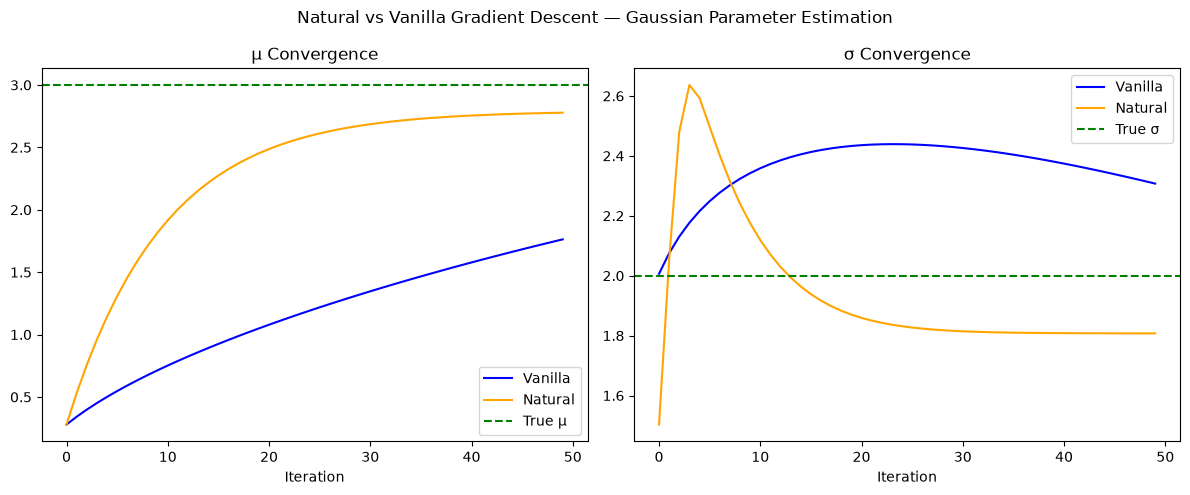

True: μ=3.0, σ=2.0
Vanilla: μ=1.7629, σ=2.3074
Natural: μ=2.7779, σ=1.8074


In [14]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

true_mu = 3.0
true_sigma = 2.0
data = np.random.normal(true_mu, true_sigma, 100)

def log_likelihood(params, data):
    mu, sigma = params
    return np.sum(-0.5 * ((data - mu) / sigma) ** 2) - len(data) * np.log(sigma)

def vanilla_gradient(params, data):
    mu, sigma = params
    dmu = np.mean((data - mu) / sigma**2)
    dsigma = np.mean(((data - mu)**2 / sigma**3) - (1/sigma))
    return np.array([dmu, dsigma])

def fisher_matrix(params):
    mu, sigma = params
    return np.array([
        [1/sigma**2, 0],
        [0, 2/sigma**4]
    ])

def natural_gradient(params, data):
    F = fisher_matrix(params)
    grad = vanilla_gradient(params, data)
    return np.linalg.inv(F) @ grad

# Starting far from true values to see difference clearly
params_vanilla = np.array([0.0, 1.0])
params_natural = np.array([0.0, 1.0])

learning_rate = 0.1
iterations = 50

vanilla_history = []
natural_history = []

for i in range(iterations):
    params_vanilla += learning_rate * vanilla_gradient(params_vanilla, data)
    params_natural += learning_rate * natural_gradient(params_natural, data)
    vanilla_history.append(params_vanilla.copy())
    natural_history.append(params_natural.copy())

vanilla_history = np.array(vanilla_history)
natural_history = np.array(natural_history)

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(vanilla_history[:, 0], label='Vanilla', color='blue')
axes[0].plot(natural_history[:, 0], label='Natural', color='orange')
axes[0].axhline(y=true_mu, color='green', linestyle='--', label='True μ')
axes[0].set_title('μ Convergence')
axes[0].set_xlabel('Iteration')
axes[0].legend()

axes[1].plot(vanilla_history[:, 1], label='Vanilla', color='blue')
axes[1].plot(natural_history[:, 1], label='Natural', color='orange')
axes[1].axhline(y=true_sigma, color='green', linestyle='--', label='True σ')
axes[1].set_title('σ Convergence')
axes[1].set_xlabel('Iteration')
axes[1].legend()

plt.suptitle('Natural vs Vanilla Gradient Descent — Gaussian Parameter Estimation')
plt.tight_layout()
plt.savefig('convergence.png')
plt.show()

print(f"True: μ={true_mu}, σ={true_sigma}")
print(f"Vanilla: μ={params_vanilla[0]:.4f}, σ={params_vanilla[1]:.4f}")
print(f"Natural: μ={params_natural[0]:.4f}, σ={params_natural[1]:.4f}")